<a href="https://colab.research.google.com/github/venkateshkumarsingaravelu/machine_learning_workshop/blob/main/machine_learning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import the dataset from Kaggle
# Understand the features
# Data distributed
# Data visualization
# EDA like cleansing the data
# Feature selection and supervised machine learning alogorithim


In [6]:
from google.colab import files
uploaded = files.upload()


Saving all_egypt_hotels.csv to all_egypt_hotels.csv


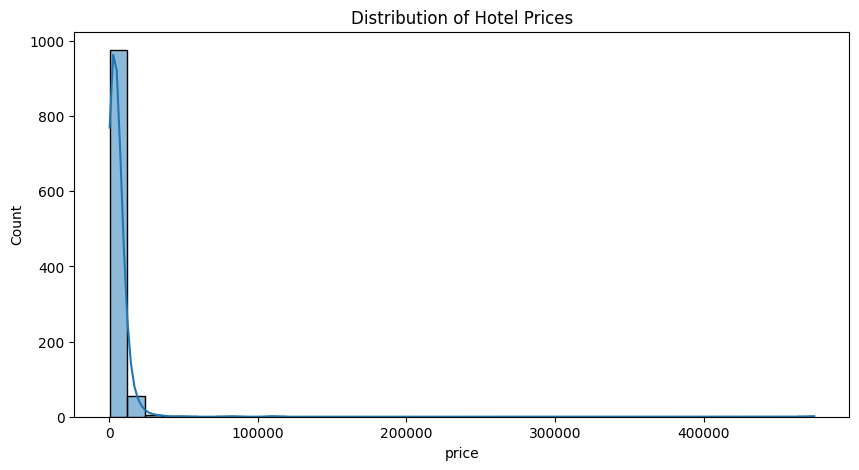

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(result['price'], bins=40, kde=True)
plt.title("Distribution of Hotel Prices")
plt.show()


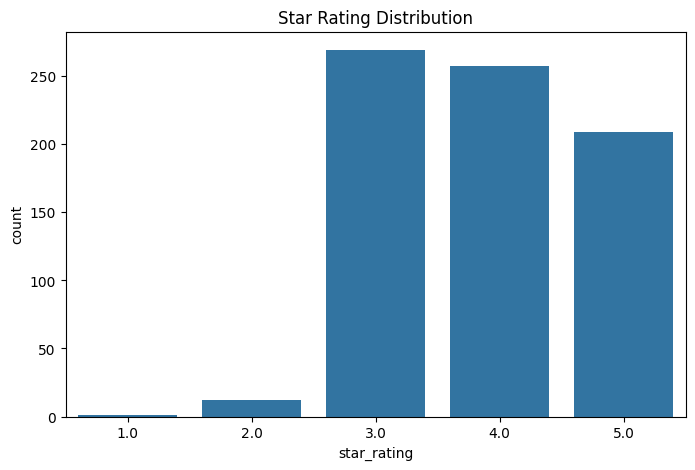

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x='star_rating', data=result)
plt.title("Star Rating Distribution")
plt.show()

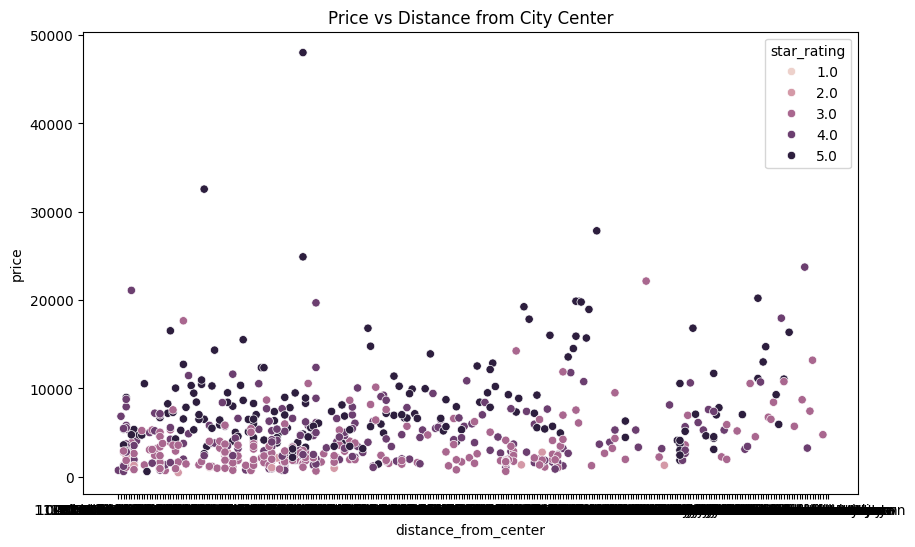

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=result, x='distance_from_center', y='price', hue='star_rating')
plt.title("Price vs Distance from City Center")
plt.show()

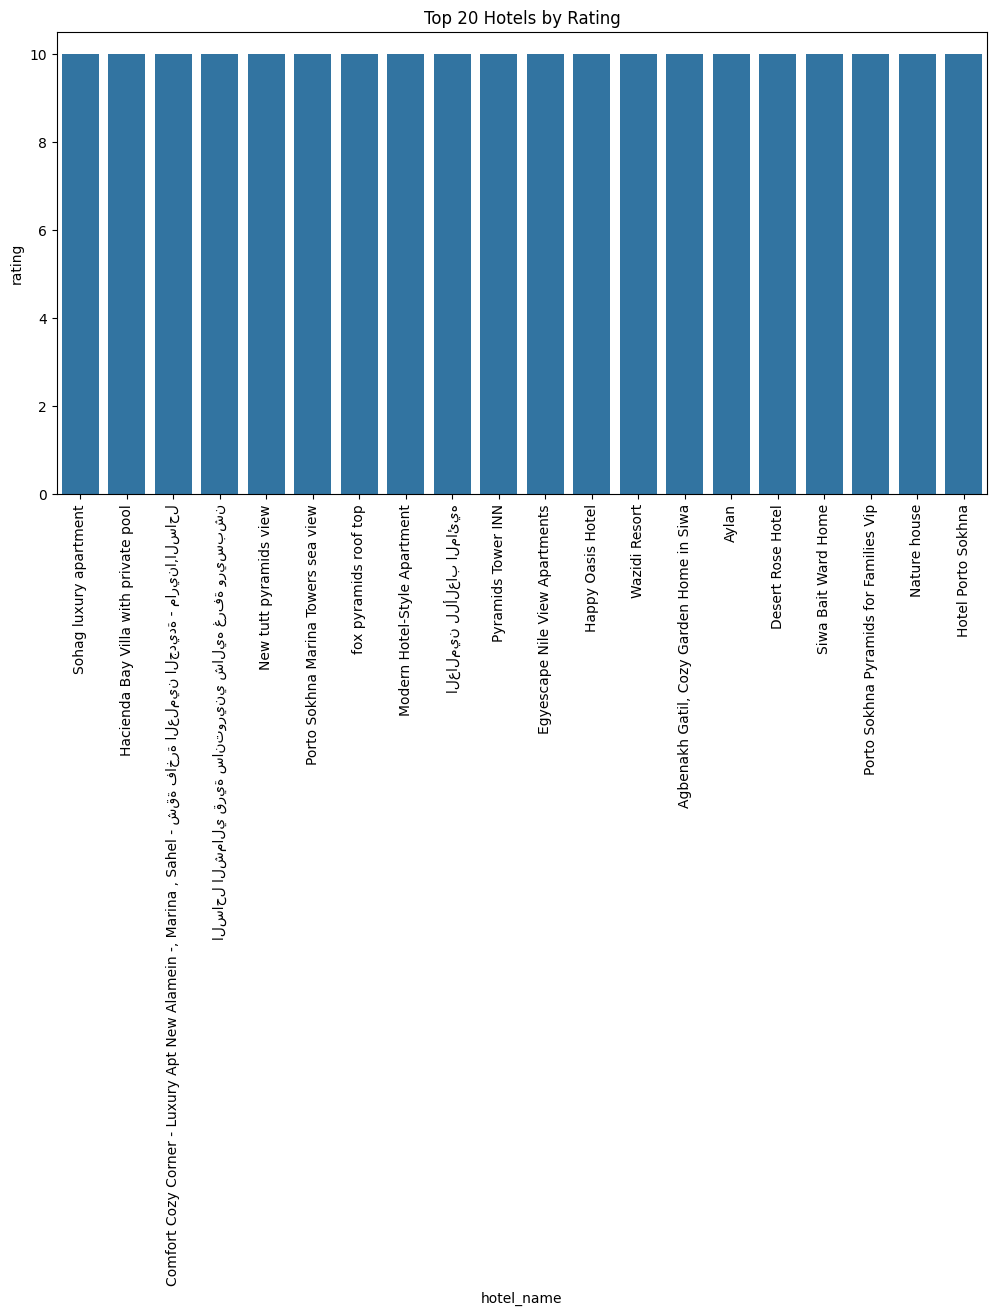

In [22]:
top_hotels = result.sort_values('rating', ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(data=top_hotels, x='hotel_name', y='rating')
plt.xticks(rotation=90)
plt.title("Top 20 Hotels by Rating")
plt.show()


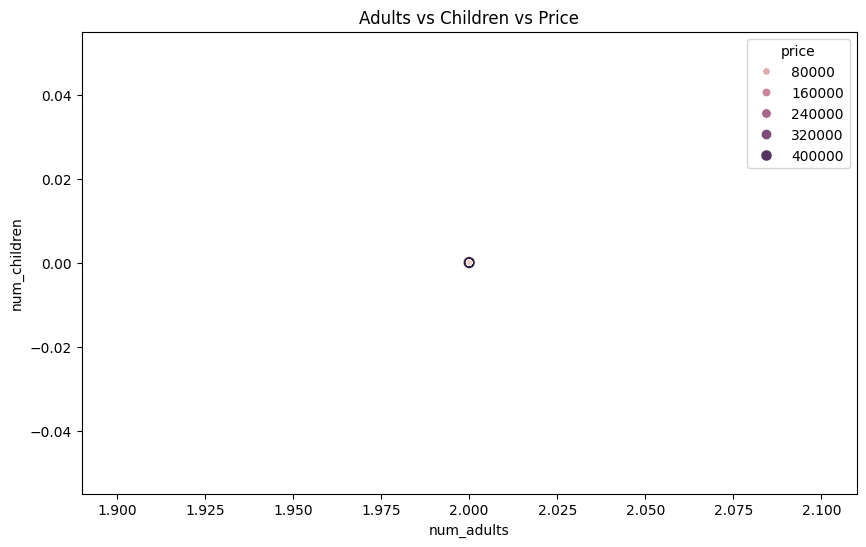

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=result, x='num_adults', y='num_children', size='price', hue='price')
plt.title("Adults vs Children vs Price")
plt.show()


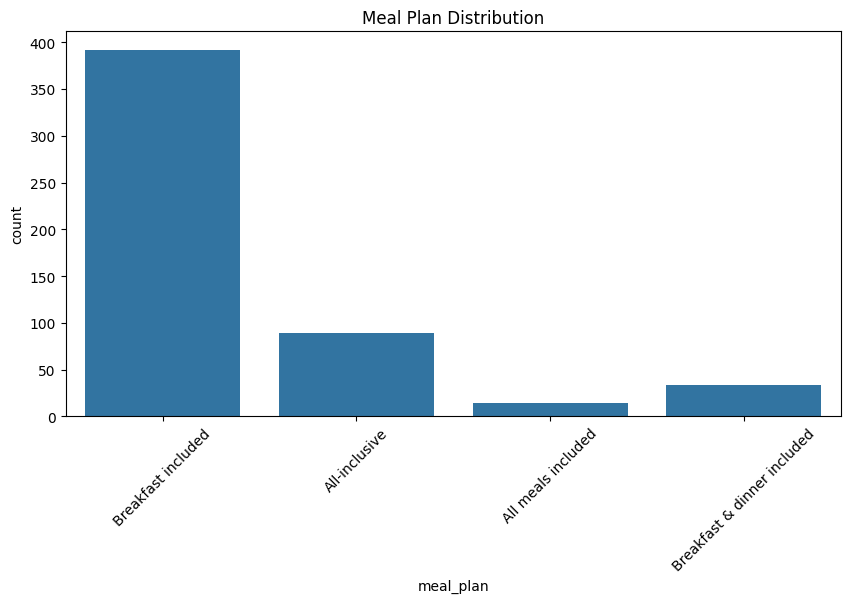

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(data=result, x='meal_plan')
plt.xticks(rotation=45)
plt.title("Meal Plan Distribution")
plt.show()


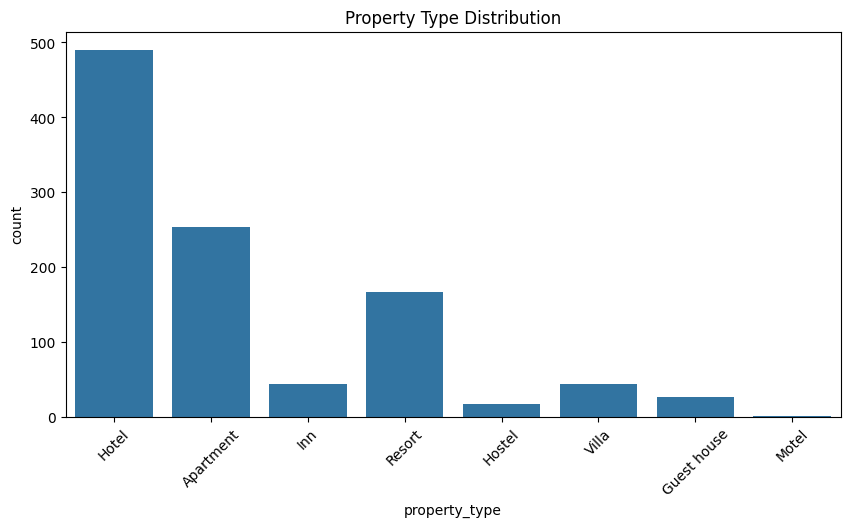

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(data=result, x='property_type')
plt.xticks(rotation=45)
plt.title("Property Type Distribution")
plt.show()


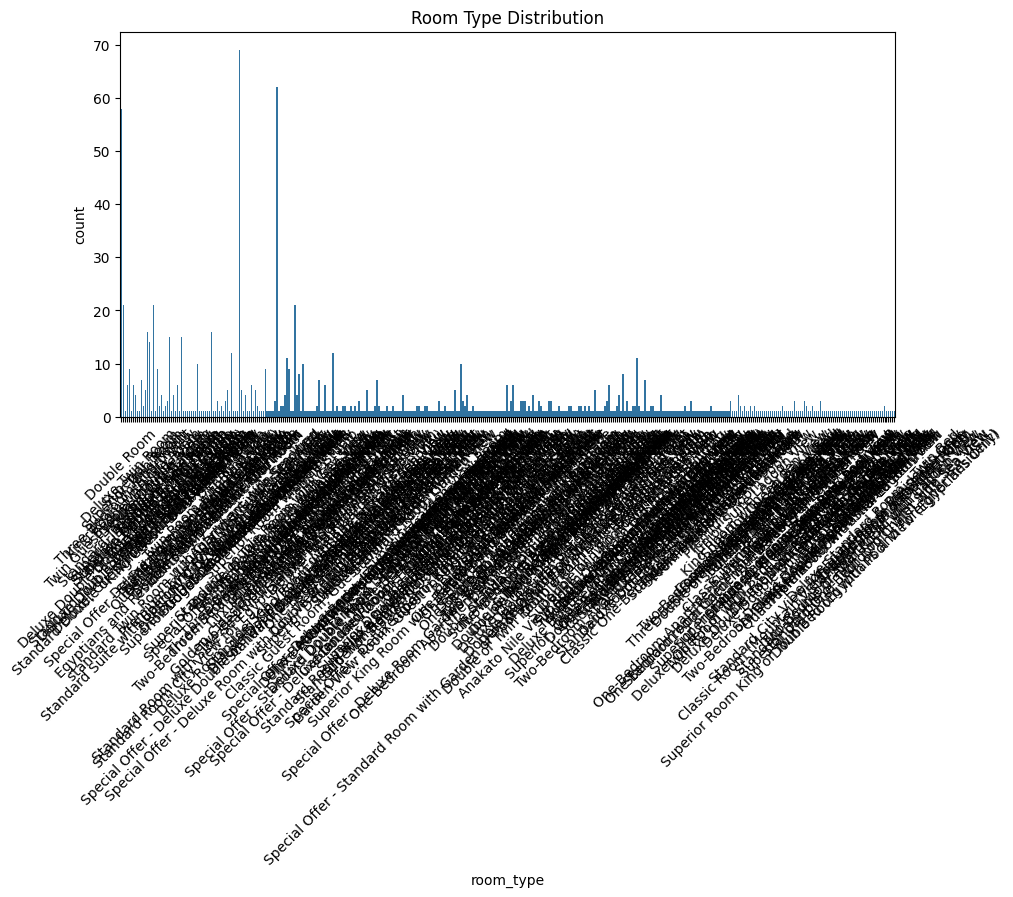

In [27]:
plt.figure(figsize=(10,5))
sns.countplot(data=result, x='room_type')
plt.xticks(rotation=45)
plt.title("Room Type Distribution")
plt.show()


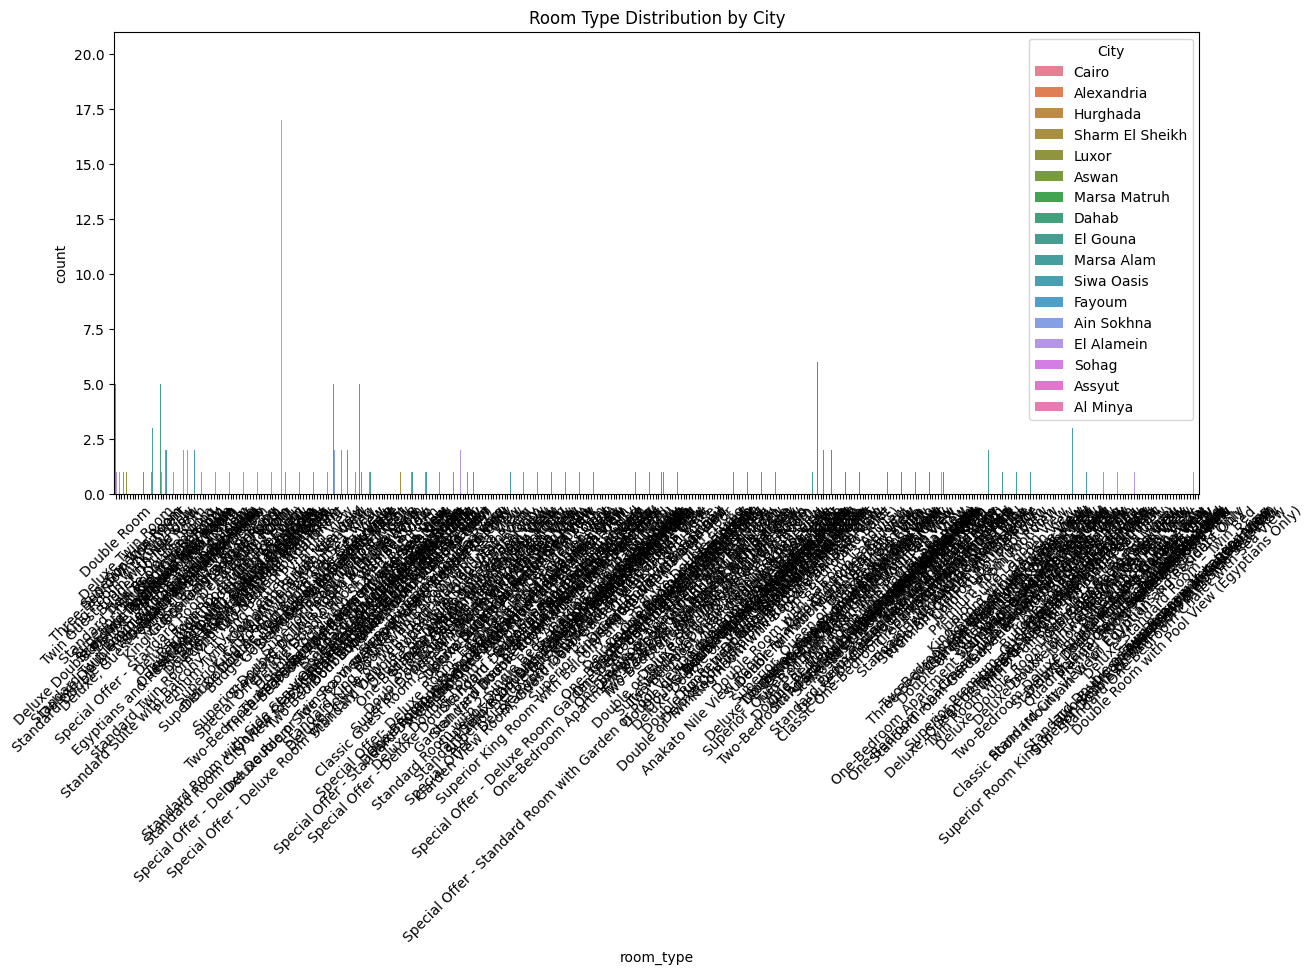

In [28]:
plt.figure(figsize=(14,6))
sns.countplot(data=result, x='room_type', hue='city')
plt.xticks(rotation=45)
plt.title("Room Type Distribution by City")
plt.legend(title='City')
plt.show()


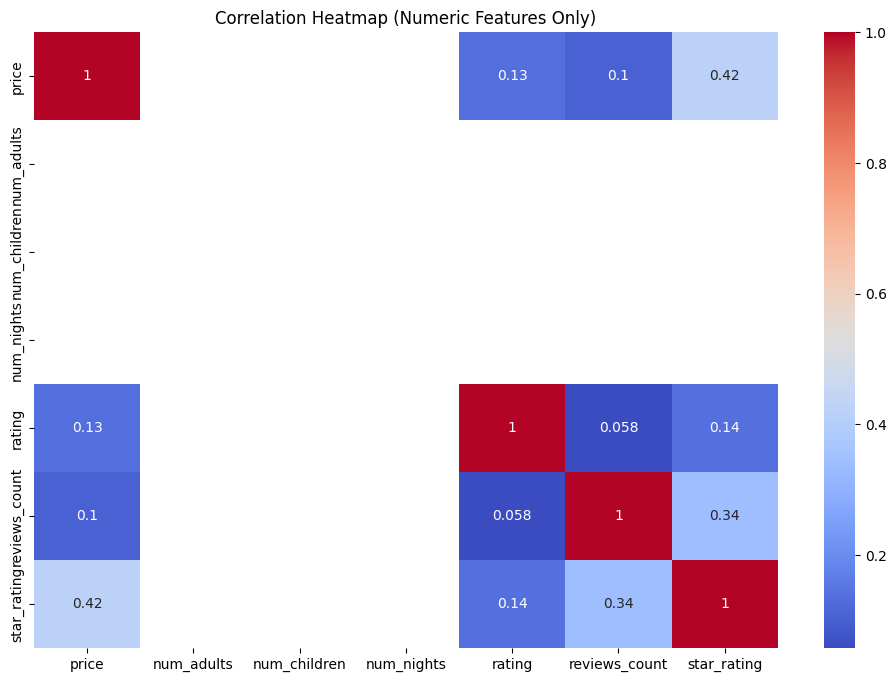

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = result.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()


In [34]:
#  EDA

result.head()
result.info()
result.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   city                  1040 non-null   object 
 1   hotel_name            1040 non-null   object 
 2   price                 1040 non-null   int64  
 3   currency              1040 non-null   object 
 4   num_adults            1040 non-null   int64  
 5   num_children          1040 non-null   int64  
 6   num_nights            1040 non-null   int64  
 7   rating                945 non-null    float64
 8   reviews_count         945 non-null    float64
 9   location              1040 non-null   object 
 10  distance_from_center  882 non-null    object 
 11  star_rating           748 non-null    float64
 12  property_type         1040 non-null   object 
 13  room_type             1040 non-null   object 
 14  free_cancellation     1040 non-null   object 
 15  meal_plan            

,city,hotel_name,price,currency,num_adults,num_children,num_nights,rating,reviews_count,location,distance_from_center,star_rating,property_type,room_type,free_cancellation,meal_plan,amenities,hotel_url,scraped_date
count,1040,1040,1040.000000,1040,1040.0,1040.0,1040.0,945.000000,945.000000,1040,882,748.000000,1040,1040,1040,529,662,1040,1040
unique,17,1029,NaN,1,NaN,NaN,NaN,NaN,NaN,65,274,NaN,8,388,2,4,85,1040,1
top,Cairo,Steigenberger Golf Resort El Gouna,NaN,EGP,NaN,NaN,NaN,NaN,NaN,"El Gouna, Hurghada",0.8 km from downtown,NaN,Hotel,Two-Bedroom Apartment,Yes,Breakfast included,"Free parking, Bar, Restaurant",https://www.booking.com/hotel/eg/assuit-ultra-...,5/9/2026
freq,75,2,NaN,1040,NaN,NaN,NaN,NaN,NaN,77,24,NaN,490,69,590,392,62,1,1040
mean,NaN,NaN,5378.347115,NaN,2.0,0.0,1.0,8.454603,715.697354,NaN,NaN,3.883690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,15768.816913,NaN,0.0,0.0,0.0,1.146033,1381.203197,NaN,NaN,0.838243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,264.000000,NaN,2.0,0.0,1.0,1.000000,1.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,1845.000000,NaN,2.0,0.0,1.0,8.000000,26.000000,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,3427.000000,NaN,2.0,0.0,1.0,8.600000,151.000000,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,6140.000000,NaN,2.0,0.0,1.0,9.200000,778.000000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# Handle Missing Values
result.isnull().sum()

# Example fixes:
result['price'] = result['price'].fillna(result['price'].median())
result['rating'] = result['rating'].fillna(result['rating'].median())
result['reviews_count'] = result['reviews_count'].fillna(0)


In [37]:
#  Convert the data types in order to work for other data types
result['scraped_date'] = pd.to_datetime(result['scraped_date'])
result['free_cancellation'] = result['free_cancellation'].astype('category')
result['meal_plan'] = result['meal_plan'].astype('category')


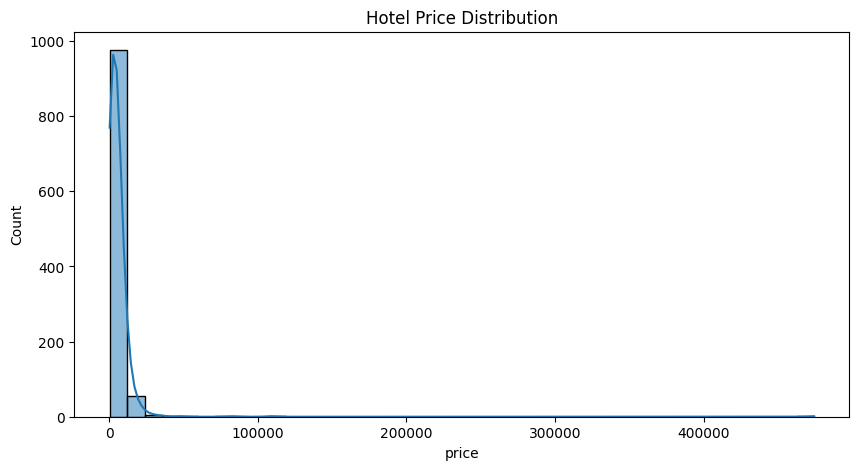

In [38]:
# Univariate Analysis (Single Column)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(result['price'], bins=40, kde=True)
plt.title("Hotel Price Distribution")
plt.show()


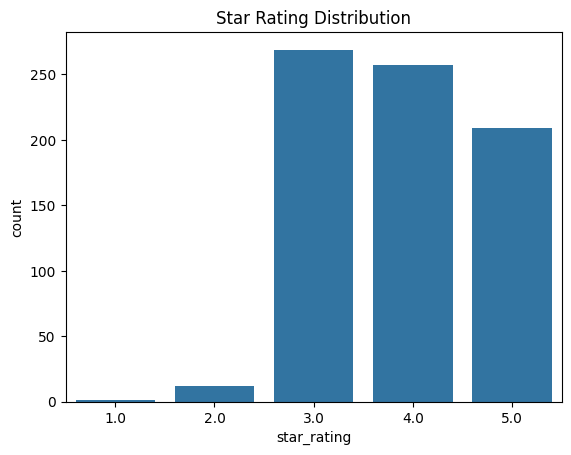

In [39]:
sns.countplot(data=result, x='star_rating')
plt.title("Star Rating Distribution")
plt.show()


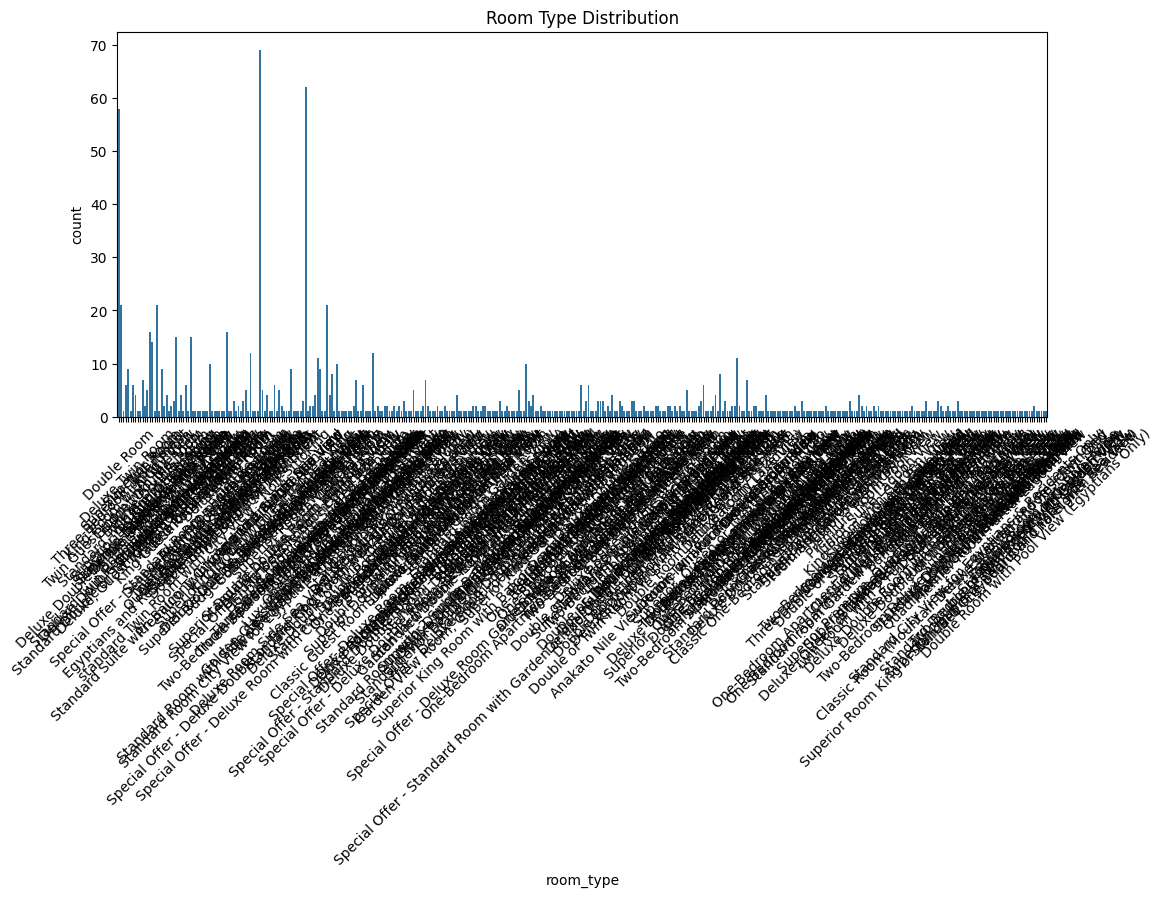

In [40]:
plt.figure(figsize=(12,5))
sns.countplot(data=result, x='room_type')
plt.xticks(rotation=45)
plt.title("Room Type Distribution")
plt.show()


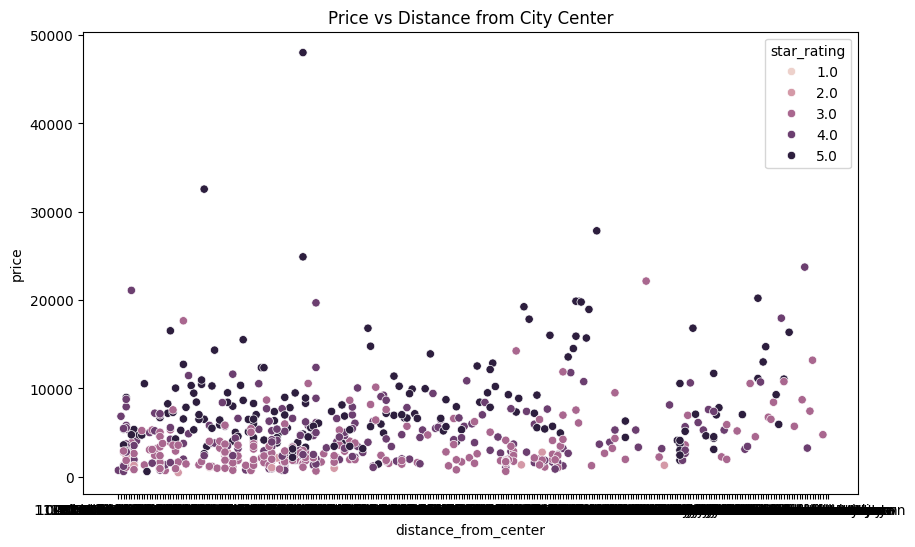

In [41]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=result, x='distance_from_center', y='price', hue='star_rating')
plt.title("Price vs Distance from City Center")
plt.show()


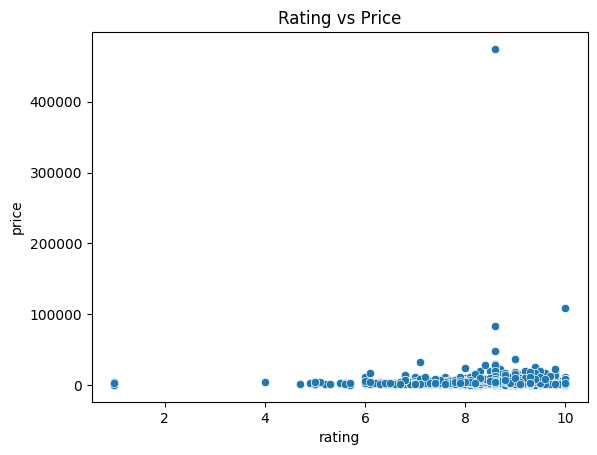

In [42]:
sns.scatterplot(data=result, x='rating', y='price')
plt.title("Rating vs Price")
plt.show()


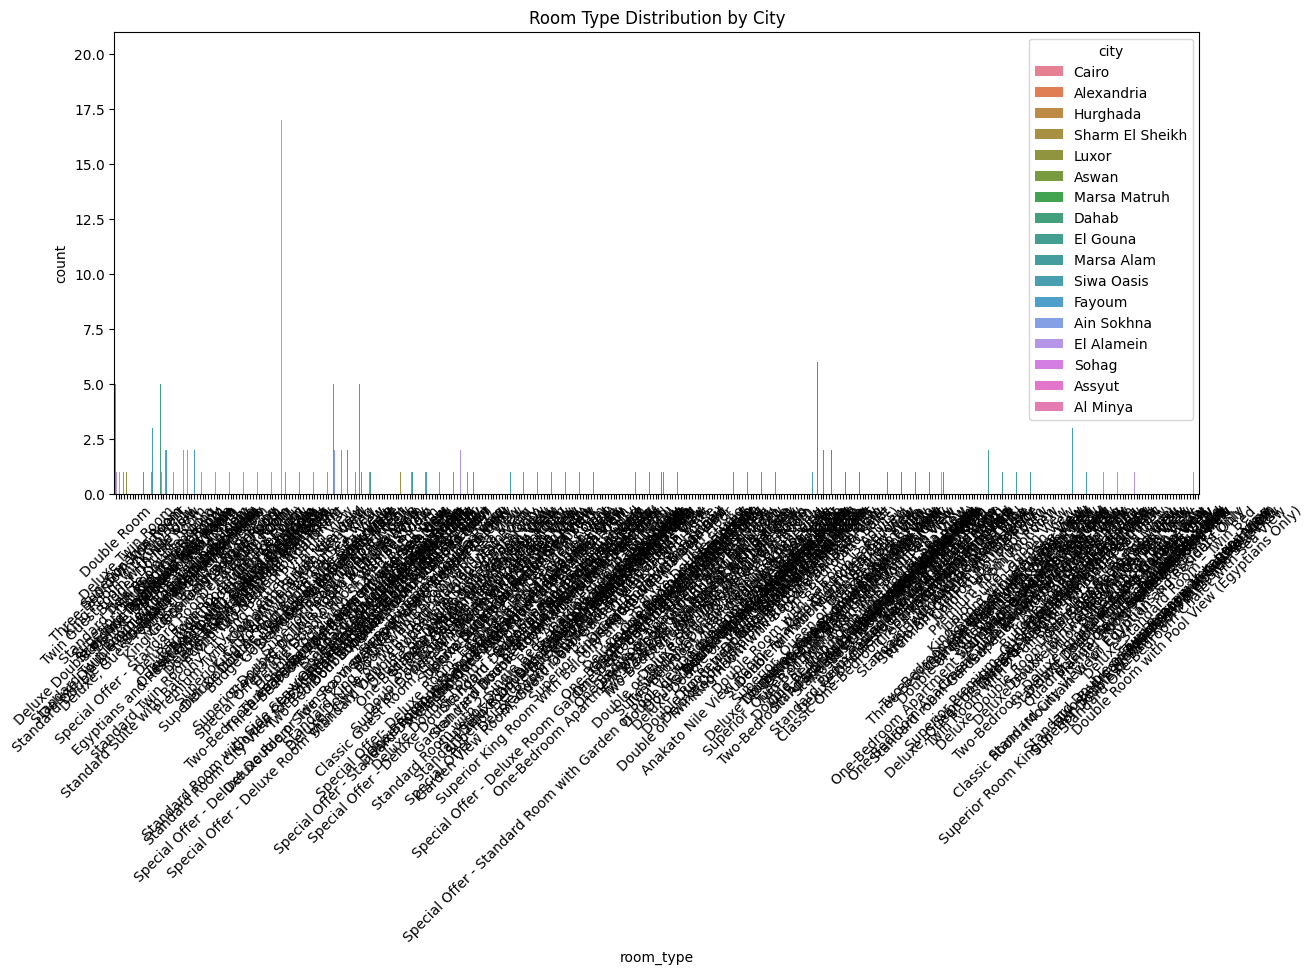

In [43]:
plt.figure(figsize=(14,6))
sns.countplot(data=result, x='room_type', hue='city')
plt.xticks(rotation=45)
plt.title("Room Type Distribution by City")
plt.show()


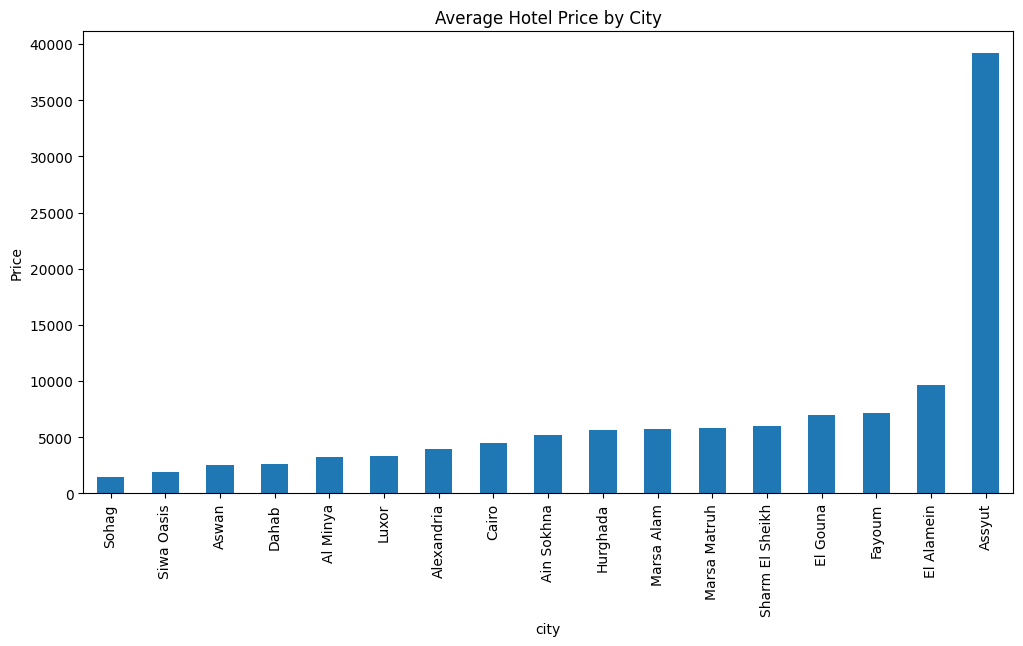

In [45]:
city_price = result.groupby('city')['price'].mean().sort_values()

city_price.plot(kind='bar', figsize=(12,6))
plt.title("Average Hotel Price by City")
plt.ylabel("Price")
plt.show()


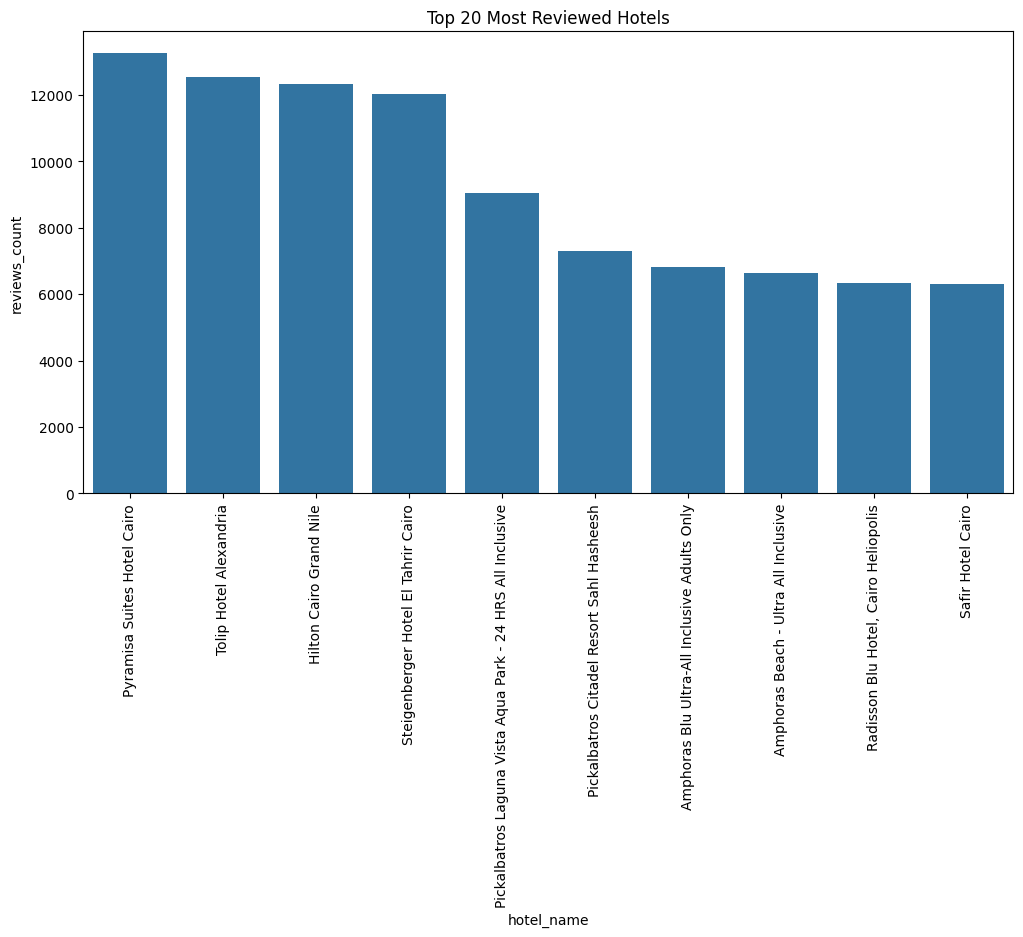

In [47]:
top_reviews = result.sort_values('reviews_count', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top_reviews, x='hotel_name', y='reviews_count')
plt.xticks(rotation=90)
plt.title("Top 20 Most Reviewed Hotels")
plt.show()


In [49]:
result['amenities_list'] = result['amenities'].fillna("").str.split(',')

from collections import Counter

amenities = Counter(
    a.strip()
    for lst in result['amenities_list']
    for a in lst
    if a.strip() != ""
)

top_amenities = pd.Series(amenities).sort_values(ascending=False).head(20)
top_amenities


,0
Free parking,413
Free Wifi,285
Restaurant,249
Bar,209
Hot tub/Jacuzzi,146
24-hour front desk,139
Spa,97
Heated pool,94
Airport shuttle (free),20
Adults only,20


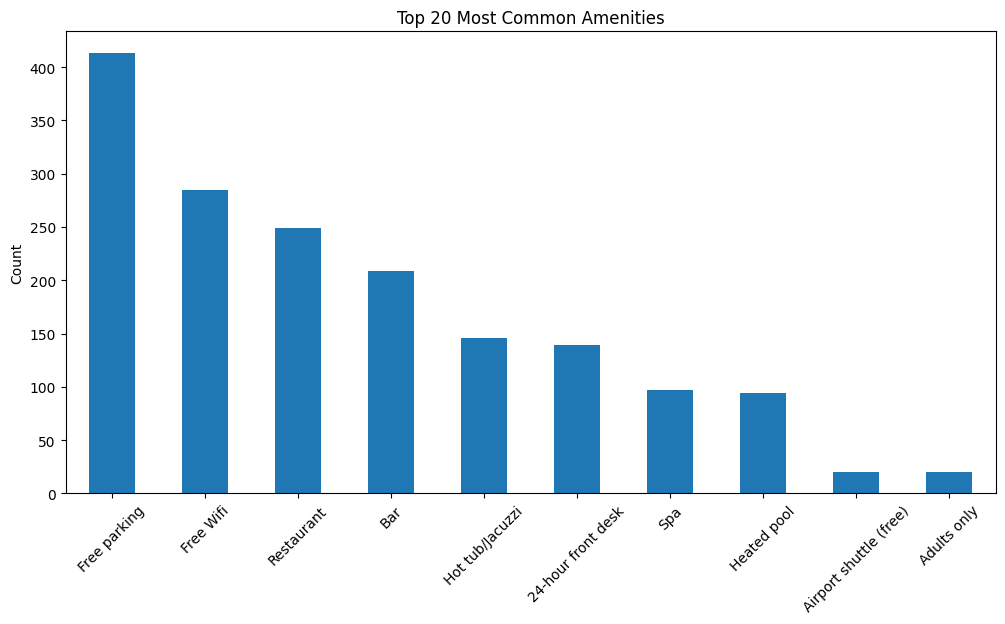

In [50]:
plt.figure(figsize=(12,6))
top_amenities.plot(kind='bar')
plt.title("Top 20 Most Common Amenities")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


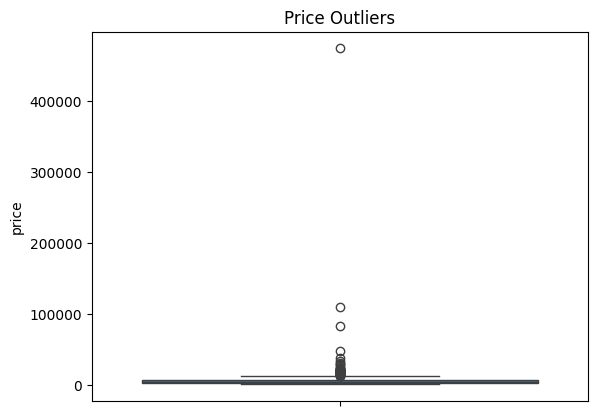

In [51]:
sns.boxplot(data=result['price'])
plt.title("Price Outliers")
plt.show()


Explained variance ratio: [0.3451313 0.201628 ]


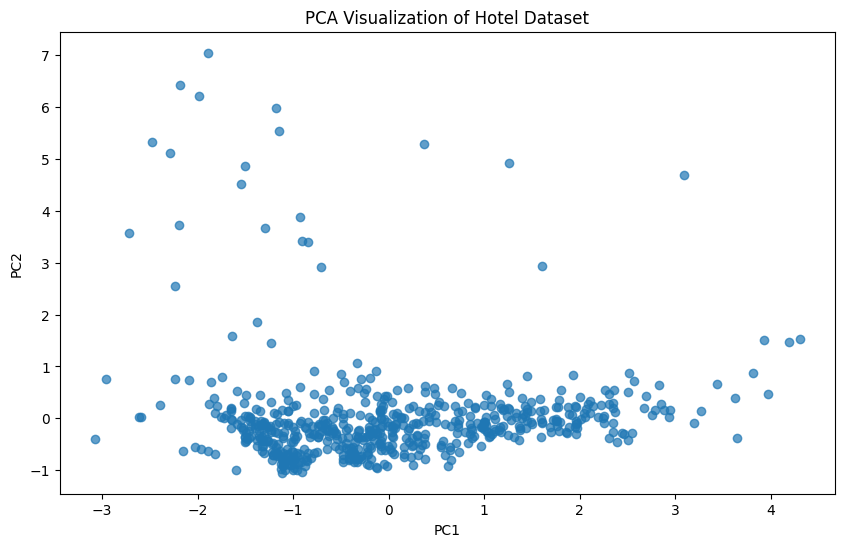

In [53]:
# ---------------------------------------------
# 1. Import libraries
# ---------------------------------------------
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---------------------------------------------
# 2. Load dataset
# ---------------------------------------------
df = pd.read_csv("all_egypt_hotels.csv")

# ---------------------------------------------
# 3. Clean distance_from_center
# ---------------------------------------------
def extract_distance(x):
    if isinstance(x, str):
        # Extract numeric value
        num = re.findall(r"[\d\.]+", x)
        if not num:
            return None
        num = float(num[0])

        # Convert meters → km
        if "m" in x.lower():
            return num / 1000
        return num
    return x

df['distance_from_center_clean'] = df['distance_from_center'].apply(extract_distance)

# ---------------------------------------------
# 4. Select numeric columns for ML
# ---------------------------------------------
num_df = df[['price',
             'num_adults',
             'num_children',
             'num_nights',
             'rating',
             'reviews_count',
             'distance_from_center_clean',
             'star_rating']]

# Drop rows with missing numeric values
num_df = num_df.dropna()

# ---------------------------------------------
# 5. Scale numeric features
# ---------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df)

# ---------------------------------------------
# 6. PCA (2 components)
# ---------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# ---------------------------------------------
# 7. PCA Visualization
# ---------------------------------------------
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
plt.title("PCA Visualization of Hotel Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [11]:
import pandas as pd

result = pd.read_csv('all_egypt_hotels.csv')

In [10]:
# Mohnt from google drive
# import pandas as pd

# df = pd.read_csv('/content/drive/MyDrive/your_folder/your_file.csv')
# df.head()


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/your_folder/your_file.csv'

In [9]:
# #  If you want to try to load from github.com
# import pandas as pd

# url = "https://github.com/venkateshkumarsingaravelu/machine_learning_workshop/blob/3cce49f6ff61c77683f44510822ad398e2ddb5aa/all_egypt_hotels.csv"
# df = pd.read_csv(url)
# df.head()


ParserError: Error tokenizing data. C error: Expected 1 fields in line 38, saw 2


In [12]:
result.head(10)

,city,hotel_name,price,currency,num_adults,num_children,num_nights,rating,reviews_count,location,distance_from_center,star_rating,property_type,room_type,free_cancellation,meal_plan,amenities,hotel_url,scraped_date
0,Cairo,Regant pyramids hotel,715,EGP,2,0,1,10.0,1.0,"Giza, Cairo",11.3 km from downtown,4.0,Hotel,Double Room,Yes,Breakfast included,"Hot tub/Jacuzzi, Spa, Bar",https://www.booking.com/hotel/eg/regant-pyrami...,5/9/2026
1,Cairo,Sky-lounge,3606,EGP,2,0,1,NaN,NaN,"Maadi, Cairo",10.2 km from downtown,NaN,Apartment,Three-Bedroom Apartment,No,NaN,Free parking,https://www.booking.com/hotel/eg/sky-lounge.ht...,5/9/2026
2,Cairo,Hilton Cairo Grand Nile,5377,EGP,2,0,1,8.0,12311.0,Cairo,1.4 km from downtown,5.0,Hotel,Twin Guest room with Nile View,Yes,NaN,"Hot tub/Jacuzzi, Spa",https://www.booking.com/hotel/eg/grand-nile-to...,5/9/2026
3,Cairo,Agor-Cairo Hotel Downtown,7908,EGP,2,0,1,10.0,7.0,Cairo,0.8 km from downtown,4.0,Hotel,Deluxe Double or Twin Room with City View,Yes,Breakfast included,"Hot tub/Jacuzzi, Spa, Bar",https://www.booking.com/hotel/eg/agor-cairo-do...,5/9/2026
4,Cairo,gold cairo downtown,5272,EGP,2,0,1,NaN,NaN,Cairo,100 m from downtown,4.0,Hotel,Double Room,Yes,Breakfast included,"Hot tub/Jacuzzi, Spa, Bar",https://www.booking.com/hotel/eg/gold-cairo-do...,5/9/2026
5,Cairo,cairoooo houb,2900,EGP,2,0,1,NaN,NaN,Cairo,200 m from downtown,4.0,Hotel,Deluxe Twin Room,Yes,Breakfast included,"Hot tub/Jacuzzi, Free parking, Spa",https://www.booking.com/hotel/eg/cairoooo-houb...,5/9/2026
6,Cairo,Ramses Hilton Hotel & Casino,5333,EGP,2,0,1,8.5,5243.0,Cairo,0.7 km from downtown,5.0,Hotel,King Room with City View,Yes,NaN,"Heated pool, Bar",https://www.booking.com/hotel/eg/ramses-hilton...,5/9/2026
7,Cairo,Novotel Cairo Airport,4059,EGP,2,0,1,7.6,3572.0,"Heliopolis, Cairo",18.2 km from downtown,4.0,Hotel,Superior Twin Room,No,NaN,"Hot tub/Jacuzzi, Airport shuttle (free)",https://www.booking.com/hotel/eg/novotel-cairo...,5/9/2026
8,Cairo,Le Passage Cairo Hotel & Casino,4705,EGP,2,0,1,8.5,3755.0,"Heliopolis, Cairo",18.1 km from downtown,5.0,Hotel,Standard Double or Twin Room with Garden View,Yes,NaN,"Airport shuttle (free), Bar, Restaurant",https://www.booking.com/hotel/eg/le-passage-ca...,5/9/2026
9,Cairo,Holiday Inn Citystars by IHG,4705,EGP,2,0,1,7.6,1757.0,"Nasr City, Cairo",10.9 km from downtown,5.0,Inn,Standard Twin Room - Smoking,Yes,NaN,"Restaurant, 24-hour front desk",https://www.booking.com/hotel/eg/holiday-inn.h...,5/9/2026


In [15]:
result.describe()

,price,num_adults,num_children,num_nights,rating,reviews_count,star_rating
count,1040.000000,1040.0,1040.0,1040.0,945.000000,945.000000,748.000000
mean,5378.347115,2.0,0.0,1.0,8.454603,715.697354,3.883690
std,15768.816913,0.0,0.0,0.0,1.146033,1381.203197,0.838243
min,264.000000,2.0,0.0,1.0,1.000000,1.000000,1.000000
25%,1845.000000,2.0,0.0,1.0,8.000000,26.000000,3.000000
50%,3427.000000,2.0,0.0,1.0,8.600000,151.000000,4.000000
75%,6140.000000,2.0,0.0,1.0,9.200000,778.000000,5.000000
max,474480.000000,2.0,0.0,1.0,10.000000,13240.000000,5.000000


In [16]:
result.describe(include='all')

,city,hotel_name,price,currency,num_adults,num_children,num_nights,rating,reviews_count,location,distance_from_center,star_rating,property_type,room_type,free_cancellation,meal_plan,amenities,hotel_url,scraped_date
count,1040,1040,1040.000000,1040,1040.0,1040.0,1040.0,945.000000,945.000000,1040,882,748.000000,1040,1040,1040,529,662,1040,1040
unique,17,1029,NaN,1,NaN,NaN,NaN,NaN,NaN,65,274,NaN,8,388,2,4,85,1040,1
top,Cairo,Steigenberger Golf Resort El Gouna,NaN,EGP,NaN,NaN,NaN,NaN,NaN,"El Gouna, Hurghada",0.8 km from downtown,NaN,Hotel,Two-Bedroom Apartment,Yes,Breakfast included,"Free parking, Bar, Restaurant",https://www.booking.com/hotel/eg/assuit-ultra-...,5/9/2026
freq,75,2,NaN,1040,NaN,NaN,NaN,NaN,NaN,77,24,NaN,490,69,590,392,62,1,1040
mean,NaN,NaN,5378.347115,NaN,2.0,0.0,1.0,8.454603,715.697354,NaN,NaN,3.883690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,15768.816913,NaN,0.0,0.0,0.0,1.146033,1381.203197,NaN,NaN,0.838243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,264.000000,NaN,2.0,0.0,1.0,1.000000,1.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,1845.000000,NaN,2.0,0.0,1.0,8.000000,26.000000,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,3427.000000,NaN,2.0,0.0,1.0,8.600000,151.000000,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,6140.000000,NaN,2.0,0.0,1.0,9.200000,778.000000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
